# Lesson 7: Human-in-the-Loop

## *Pausing the Agent for Approval*

---

### Where We Are

In Lesson 6, our concierge agent gained memory through the checkpointer. It can hold multi-turn conversations and serve many users in parallel.

But there is a new problem on the horizon. So far, our tools were *safe* - looking up weather or population cannot hurt anyone. What happens when we give the agent a **dangerous** tool? Sending an email, transferring money, deleting a file, charging a credit card.

Letting an LLM execute irreversible actions on its own is reckless. We need a way to **pause** the agent right before the risky step and ask a human: *Should I really do this?*

---

### What Human-in-the-Loop Solves

LangGraph provides `interrupt()` - a function that **freezes** graph execution at a chosen point and waits. The checkpointer (Lesson 6) saves the paused state. Later, we resume with the human's decision and the graph picks up exactly where it left off.

| Without Interrupt | With Interrupt |
|:---|:---|
| Agent acts immediately | Agent waits for approval |
| Mistakes are irreversible | Mistakes are caught before they happen |
| Trust the LLM blindly | Verify, then trust |

---

### The Mental Model

> **Think of a junior banker who needs a manager's signature for any transfer.**
>
> The junior can look up balances, answer questions, print statements - all on their own. But the moment a customer says "transfer $500 to John," the junior fills out the form, puts down the pen, and walks the form over to the manager.
>
> The manager reviews: *Approve* (sign), *Reject* (tear it up), or *Edit* (cross out "$500", write "$50"). Whatever the manager decides, the junior carries out exactly.
>
> The graph is the junior. `interrupt()` is the moment they put the pen down. The checkpointer holds the half-filled form while the manager thinks. When `Command(resume=...)` is called, the junior picks up the pen and finishes the transfer with the approved values.

---

### What We Will Build

A banking agent with two tools:

| Tool | Risk Level | Needs Approval? |
|:---|:---|:---|
| `check_balance` | Safe (read-only) | No - executes immediately |
| `transfer_money` | Dangerous (moves money) | Yes - pauses for human |

We will demonstrate three scenarios:
1. **Safe action**: ask for balance -> answered directly, no pause
2. **Approved transfer**: agent pauses -> human approves -> transfer executes
3. **Rejected transfer**: agent pauses -> human rejects -> transfer cancelled

```
START -> agent -> [needs a tool?]
                     |
         +-----------+-----------+
         |                       |
        END                  approval_gate
                                 |
                          [interrupt() - PAUSE]
                                 |
                    (human approves/rejects/edits)
                                 |
                              tools -> agent -> ...
```

---

## Step 1: Setup

Same dependencies as Lesson 6.

In [12]:
!pip install -q -U langgraph langchain-openai langchain-core


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\sk72\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
import os

try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
except ImportError:
    from dotenv import load_dotenv
    load_dotenv(override=True)

In [14]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

---

## Step 2: Define the Tools

Two tools - one safe, one dangerous. Notice the tools themselves do not know about interrupts. The approval logic lives in the graph, not in the tool. This is good design: tools stay simple and reusable.

| Tool | What It Does |
|:---|:---|
| `check_balance` | Reads an account balance from a fake database |
| `transfer_money` | Moves money between accounts (the risky one) |

In [15]:
# Fake account database
ACCOUNTS = {
    "alice": 5000.00,
    "john": 1200.00,
}


@tool
def check_balance(account: str) -> str:
    """Check the current balance of an account."""
    balance = ACCOUNTS.get(account.lower())
    if balance is None:
        return f"Account '{account}' not found."
    return f"Account '{account}' has a balance of ${balance:.2f}."


@tool
def transfer_money(from_account: str, to_account: str, amount: float) -> str:
    """Transfer money from one account to another. This is a sensitive operation."""
    if from_account.lower() not in ACCOUNTS or to_account.lower() not in ACCOUNTS:
        return "One or both accounts not found."
    if ACCOUNTS[from_account.lower()] < amount:
        return "Insufficient funds."
    ACCOUNTS[from_account.lower()] -= amount
    ACCOUNTS[to_account.lower()] += amount
    return f"Transferred ${amount:.2f} from {from_account} to {to_account}."


tools = [check_balance, transfer_money]

---

## Step 3: Build the Agent and Approval Gate

The graph has three nodes:

| Node | Role |
|:---|:---|
| `agent` | LLM decides what to do (same as Lesson 5) |
| `approval_gate` | Inspects the planned tool call. If it is risky, calls `interrupt()` to pause |
| `tools` | Executes whatever the human approved (using built-in `ToolNode`) |

The magic happens in `approval_gate`. When `interrupt()` is called, the graph **stops mid-execution** and the State is saved by the checkpointer. The user sees a special return value indicating a pause.

In [16]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)


class State(TypedDict):
    messages: Annotated[list, add_messages]


def agent(state: State):
    """LLM decides what tool to call (or to respond directly)."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# Tools that require human approval before running
SENSITIVE_TOOLS = {"transfer_money"}


def approval_gate(state: State):
    """Inspect the LLM's tool call. If sensitive, pause and ask the human."""
    last_message = state["messages"][-1]
    tool_calls = last_message.tool_calls

    # Check each requested tool call
    for call in tool_calls:
        if call["name"] in SENSITIVE_TOOLS:
            # PAUSE the graph - show the human what is about to happen
            decision = interrupt({
                "action": call["name"],
                "arguments": call["args"],
                "message": f"Approve {call['name']} with {call['args']}? Reply 'approve', 'reject', or send new args."
            })

            # When resumed, `decision` is whatever the human sent via Command(resume=...)
            if decision == "reject":
                # Replace the tool call with a synthetic 'cancelled' response
                from langchain_core.messages import ToolMessage
                return {"messages": [ToolMessage(
                    content="Transfer cancelled by user.",
                    tool_call_id=call["id"]
                )]}
            elif isinstance(decision, dict):
                # Human edited the arguments - update the tool call in-place
                last_message.tool_calls[0]["args"] = decision
            # decision == "approve" -> fall through, let the tool run as-is

    # No interrupts triggered (or all approved) - pass through unchanged
    return {}


def route_after_agent(state: State) -> str:
    """After the LLM speaks, decide where to go next."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "approval_gate"
    return END


def route_after_gate(state: State) -> str:
    """After the gate, either the call was cancelled or we proceed to tools."""
    last_message = state["messages"][-1]
    # If the gate produced a ToolMessage (cancelled), skip tools and go back to agent
    from langchain_core.messages import ToolMessage
    if isinstance(last_message, ToolMessage):
        return "agent"
    return "tools"

---

## Step 4: Assemble the Graph

The new wiring: `agent -> approval_gate -> tools -> agent`. The gate sits between the LLM's decision and the tool execution, like the manager's desk between the junior banker and the cashier window.

In [17]:
workflow = StateGraph(State)

workflow.add_node("agent", agent)
workflow.add_node("approval_gate", approval_gate)
workflow.add_node("tools", ToolNode(tools))

workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    "agent",
    route_after_agent,
    {"approval_gate": "approval_gate", END: END}
)
workflow.add_conditional_edges(
    "approval_gate",
    route_after_gate,
    {"tools": "tools", "agent": "agent"}
)
workflow.add_edge("tools", "agent")

checkpointer = MemorySaver()
app = workflow.compile(checkpointer=checkpointer)

---

## Step 5: Safe Action - No Interrupt

First, a question that only needs `check_balance`. The approval gate sees a non-sensitive tool and lets it through immediately. No human intervention required.

In [18]:
config = {"configurable": {"thread_id": "banking-session-1"}}

result = app.invoke(
    {"messages": [("human", "What is the balance in Alice's account?")]},
    config=config
)
print("Q: What is the balance in Alice's account?")
print(f"A: {result['messages'][-1].content}")

Q: What is the balance in Alice's account?
A: Alice's account has a balance of $5000.00.


---

## Step 6: Risky Action - Pause and Approve

Now we ask for a money transfer. The agent will plan the tool call, the gate will see `transfer_money` is sensitive, and `interrupt()` will pause execution.

When `invoke` returns, the result will contain an `__interrupt__` key with the data we passed to `interrupt()`. The graph is *paused* in the checkpointer, waiting for us to resume.

In [19]:
config_approve = {"configurable": {"thread_id": "banking-session-approve"}}

result = app.invoke(
    {"messages": [("human", "Transfer $500 from Alice to John.")]},
    config=config_approve
)

# The graph paused inside approval_gate. Inspect what is waiting for approval.
print("Graph PAUSED at interrupt. Approval request:\n")
interrupt_info = result["__interrupt__"][0].value
for k, v in interrupt_info.items():
    print(f"  {k}: {v}")

Graph PAUSED at interrupt. Approval request:

  action: transfer_money
  arguments: {'from_account': 'Alice', 'to_account': 'John', 'amount': 500}
  message: Approve transfer_money with {'from_account': 'Alice', 'to_account': 'John', 'amount': 500}? Reply 'approve', 'reject', or send new args.


---

## Step 7: Resume with Approval

The human reviews the request and decides to approve. We resume the graph using `Command(resume="approve")`. The graph picks up exactly where it stopped - inside `approval_gate` - and continues to execute the tool.

In [20]:
# The human says: approve the transfer
result = app.invoke(
    Command(resume="approve"),
    config=config_approve
)

print("After approval:")
print(f"  Final answer: {result['messages'][-1].content}")
print(f"\n  Alice's new balance: ${ACCOUNTS['alice']:.2f}")
print(f"  John's new balance:  ${ACCOUNTS['john']:.2f}")

After approval:
  Final answer: The transfer of $500 from Alice to John has been successfully completed.

  Alice's new balance: $4500.00
  John's new balance:  $1700.00


---

## Step 8: Resume with Rejection

Now a different session. The agent plans another transfer, but this time the human rejects it. The transfer never executes, and the agent reports the cancellation to the user.

In [21]:
config_reject = {"configurable": {"thread_id": "banking-session-reject"}}

# Step 1: Agent plans the transfer, gate pauses
result = app.invoke(
    {"messages": [("human", "Transfer $1000 from Alice to John.")]},
    config=config_reject
)
print("Paused. Request:", result["__interrupt__"][0].value["arguments"])
print("---")

# Step 2: Human rejects
result = app.invoke(
    Command(resume="reject"),
    config=config_reject
)
print("\nAfter rejection:")
print(f"  Final answer: {result['messages'][-1].content}")
print(f"\n  Alice's balance (unchanged): ${ACCOUNTS['alice']:.2f}")

Paused. Request: {'from_account': 'Alice', 'to_account': 'John', 'amount': 1000}
---

After rejection:
  Final answer: It seems that the transfer was cancelled. If you would like to proceed with the transfer or need assistance with something else, please let me know!

  Alice's balance (unchanged): $4500.00


---

## Step 9: Visualize the Graph

Notice the new `approval_gate` node sitting between `agent` and `tools`. Every sensitive call must pass through it.

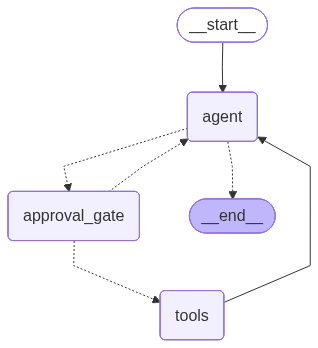

In [22]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

---

## Summary

### What Changed from Lesson 6

| Lesson 6 (Persistent Agent) | Lesson 7 (Human-in-the-Loop) |
|:---|:---|
| Agent runs to completion every time | Agent can *pause* mid-run |
| All tools execute immediately | Sensitive tools need approval first |
| State saved for memory only | State saved to support resume after pause |

---

### The Pause / Resume Cycle

```
invoke({question})        -> graph runs, hits interrupt(), STOPS
                          -> returns result with __interrupt__ key
(human reviews)
invoke(Command(resume=X)) -> graph resumes from the pause point
                          -> finishes execution, returns final answer
```

Notice we use the **same** `app.invoke` for both starting fresh and resuming. The only difference is whether we pass an input dict or a `Command(resume=...)`. The checkpointer knows the rest.

---

### Three Human Decisions

| Decision | Code | What Happens |
|:---|:---|:---|
| Approve | `Command(resume="approve")` | Tool runs with original args |
| Reject | `Command(resume="reject")` | Tool skipped, cancellation message sent back to LLM |
| Edit | `Command(resume={"amount": 50})` | Tool runs with new args |

---

### API Reference

| Component | Purpose |
|:---|:---|
| `interrupt(data)` | Pauses graph; `data` shown to human |
| `Command(resume=value)` | Restarts the graph; `value` returned by `interrupt()` |
| `result["__interrupt__"]` | The payload waiting for human input |
| Checkpointer | Required - holds the paused state |

---

### Key Takeaways

> 1. `interrupt()` pauses the graph mid-execution and returns control to the caller
> 2. The checkpointer (Lesson 6) is what makes this possible - no checkpointer, no pause/resume
> 3. Approval logic lives in a dedicated node, not in the tool - keeps tools reusable
> 4. The human can approve, reject, or *edit* the action before it runs
> 5. Resume with `Command(resume=...)` - same `invoke()`, different payload

---

**Next Lesson**: The checkpointer records State after every step - which means we have a full history. Lesson 8 introduces Time Travel: rewind the graph to any past checkpoint, fork an alternate execution from that point, and explore what-if scenarios.